# Fine-Tuning Qwen3.5-9B for Reasoning with Unsloth + LoRA

## What we're building
We're taking **Qwen3.5-9B** (a 9 billion parameter language model by Alibaba) and fine-tuning it on **OpenThoughts-114k** (a dataset of 114K reasoning examples with chain-of-thought traces) using **LoRA** (Low-Rank Adaptation) via **Unsloth** (a library that makes training 2x faster).

**By the end of this notebook, you'll have:**
- A model that reasons step-by-step before answering
- Understanding of every single line of code
- The skills to fine-tune any model on any dataset

## The Pipeline
```
Step 1: Import libraries
Step 2: Load the base model (Qwen3.5-9B) with LoRA adapters
Step 3: Load and explore the dataset (OpenThoughts-114k)
Step 4: Format the data for training
Step 5: Configure training hyperparameters
Step 6: Train!
Step 7: Test your fine-tuned model
Step 8: Save and export
```

## Step 1: Import Libraries

**What's happening here:**
- `unsloth.FastLanguageModel` — Unsloth's optimized model loader. It wraps HuggingFace Transformers but adds speed optimizations (custom CUDA kernels, memory-efficient attention).
- `torch` — PyTorch, the deep learning framework. Everything runs on top of this.
- `datasets` — HuggingFace's library for loading/processing datasets.
- `trl.SFTTrainer` — The Supervised Fine-Tuning Trainer from HuggingFace's TRL library. Handles the training loop, logging, checkpointing.
- `transformers.TrainingArguments` — Configuration object that controls ALL training behavior (learning rate, batch size, epochs, etc.).

In [1]:
import os
# Point to existing HuggingFace cache to avoid re-downloading models
os.environ["HF_HOME"] = "/home/yashb98/projects/qwen-distill/hf_cache"

import torch
from unsloth import FastLanguageModel
from datasets import load_dataset
from trl import SFTTrainer
from transformers import TrainingArguments
import matplotlib.pyplot as plt
import numpy as np

# Quick sanity check — make sure GPU is available
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
print(f"GPU:             {torch.cuda.get_device_name(0)}")
print(f"VRAM:            Unified memory with system RAM (~120 GB available)")
print(f"HF Cache:        {os.environ['HF_HOME']}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/yashb98/.conda/envs/slm-finetune/lib/python3.12/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()


Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
PyTorch version: 2.10.0+cu130
CUDA available:  True
GPU:             NVIDIA GB10
VRAM:            Unified memory with system RAM (~120 GB available)
HF Cache:        /home/yashb98/projects/qwen-distill/hf_cache


## Step 2: Load the Base Model + LoRA Adapters

**What's happening here:**
- We download Qwen3.5-9B (~18 GB) from HuggingFace
- Then attach **LoRA adapters** (r=32, alpha=64) to the model

**Why r=32 and alpha=64?**
- **Rank (r=32):** Controls the size of adapter matrices. Higher rank = more capacity to learn complex patterns. r=32 is the sweet spot for reasoning tasks — 2x the capacity of r=16, enough to capture reasoning patterns without overfitting.
- **Alpha (α=64 = 2×r):** Controls how strongly LoRA updates affect the model. The formula is: `output = base_output + (α/r) × lora_output`. With α=2r, the scaling factor is 2.0 — more aggressive updates that help the model learn reasoning faster.
- **Trainable params:** ~108M out of 9.3B (~1.16%) — still extremely efficient!

In [2]:
# ============================================================
# STEP 2A: Load the base model
# ============================================================
# This downloads Qwen3.5-9B from HuggingFace (~18 GB download)
# First time will take a while. Subsequent runs use cache.

model_name = "Qwen/Qwen3.5-9B"
max_seq_length = 4096  # Max context length (tokens). Qwen3.5 supports up to 128K, but 4K saves memory.

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_name,
    max_seq_length=max_seq_length,
    load_in_4bit=False,          # DO NOT use 4-bit for Qwen3.5 (Unsloth warns against it)
    dtype=torch.bfloat16,        # bf16 = good precision, half the memory of float32
)

print(f"Model loaded: {model_name}")
print(f"Parameters:   {model.num_parameters():,}")
print(f"Dtype:        {model.dtype}")

==((====))==  Unsloth 2026.4.4: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GB10. Num GPUs = 1. Max memory: 119.692 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu130. CUDA: 12.1. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

Model loaded: Qwen/Qwen3.5-9B
Parameters:   9,409,813,744
Dtype:        torch.bfloat16


In [3]:
# ============================================================
# STEP 2B: Attach LoRA adapters to the model
# ============================================================
# This is where the magic happens. Instead of training all 9B parameters,
# we add tiny adapter matrices to specific layers and ONLY train those.
#
# Think of it like this:
#   - The base model is a textbook (frozen, don't modify)
#   - LoRA adapters are sticky notes you add to pages (trainable)
#   - The sticky notes adjust the model's behavior without rewriting the textbook

model = FastLanguageModel.get_peft_model(
    model,
    r=32,                   # Rank: size of adapter matrices. Higher = more capacity.
                            # 16 = balanced, 32 = strong (recommended for reasoning), 64 = heavy
                            # We use 32 for better reasoning pattern capture.
    
    lora_alpha=64,          # Scaling factor. We use alpha = 2*r (scaling factor of 2.0).
                            # Formula: output = base_output + (alpha/r) * lora_output
                            # With alpha=2r, scaling is 2.0 — more aggressive LoRA updates.
                            # This is the standard for reasoning fine-tuning tasks.
    
    lora_dropout=0,         # Unsloth optimizes this away. Keep at 0.
    
    target_modules=[        # Which layers get LoRA adapters:
        "q_proj",           #   Query projection  — "what am I looking for?"
        "k_proj",           #   Key projection    — "what do I contain?"
        "v_proj",           #   Value projection  — "what information do I carry?"
        "o_proj",           #   Output projection — combines attention results
        "gate_proj",        #   Feed-forward gate — controls information flow
        "up_proj",          #   Feed-forward up   — expands representation
        "down_proj",        #   Feed-forward down — compresses back
    ],
    
    use_gradient_checkpointing="unsloth",  # Save ~30% memory by recomputing activations
    random_state=42,                        # Reproducibility seed
)

# Show how many parameters we're actually training
model.print_trainable_parameters()
# With r=32, expect ~108M trainable params (~1.16% of 9.3B)
# That's 2x more than r=16, but still tiny compared to the full model.

Unsloth: Making `model.base_model.model.model.language_model` require gradients
trainable params: 58,195,968 || all params: 9,468,009,712 || trainable%: 0.6147


## Step 3: Load and Explore the Dataset

**What's happening here:**

We load [OpenThoughts-114k](https://huggingface.co/datasets/open-thoughts/OpenThoughts-114k) — a dataset of 114K reasoning examples.

**Dataset format:**
```json
{
  "system": "Your role as an assistant involves thoroughly exploring questions...",
  "conversations": [
    {"from": "user", "value": "Solve this math problem..."},
    {"from": "assistant", "value": "<|begin_of_thought|>\nLet me think step by step...\n<|end_of_thought|>\n\n<|begin_of_solution|>\nThe answer is...\n<|end_of_solution|>"}
  ]
}
```

The reasoning is wrapped in special tags:
- `<|begin_of_thought|>` ... `<|end_of_thought|>` — The model's internal reasoning (chain-of-thought)
- `<|begin_of_solution|>` ... `<|end_of_solution|>` — The final answer

**For our first run, we'll use a 10K subset** to keep training fast (~1 hour). Once we confirm everything works, we can scale to the full 114K.

In [4]:
# ============================================================
# STEP 3A: Load the dataset
# ============================================================

dataset = load_dataset("open-thoughts/OpenThoughts-114k", split="train")

print(f"Dataset size:   {len(dataset):,} examples")
print(f"Columns:        {dataset.column_names}")
print(f"First example keys: {list(dataset[0].keys())}")
print(f"\nSystem prompt (first 200 chars):\n{dataset[0]['system'][:200]}...")

Dataset size:   113,957 examples
Columns:        ['system', 'conversations']
First example keys: ['system', 'conversations']

System prompt (first 200 chars):
Your role as an assistant involves thoroughly exploring questions through a systematic long thinking process before providing the final precise and accurate solutions. This requires engaging in a comp...


In [5]:
# ============================================================
# STEP 3B: Explore one example in detail
# ============================================================
# Let's look at what the model will learn from

example = dataset[0]
conversations = example["conversations"]

print(f"Number of turns: {len(conversations)}")
print(f"\n{'='*60}")
print(f"USER MESSAGE (first 300 chars):")
print(f"{'='*60}")
print(conversations[0]["value"][:300])

print(f"\n{'='*60}")
print(f"ASSISTANT RESPONSE (first 500 chars):")
print(f"{'='*60}")
print(conversations[1]["value"][:500])

print(f"\n{'='*60}")
print(f"ASSISTANT RESPONSE (last 300 chars):")
print(f"{'='*60}")
print(conversations[1]["value"][-300:])

# Show the length distribution
response_lengths = [len(ex["conversations"][1]["value"]) for ex in dataset.select(range(100))]
avg_len = sum(response_lengths) / len(response_lengths)
print(f"\nAverage response length (first 100 examples): {avg_len:,.0f} characters")

Number of turns: 2

USER MESSAGE (first 300 chars):
Generate an executable Python function generated from the given prompt. The function should take stdin as input and print the output. Simply call the function after the definition.The Chef likes to stay in touch with his staff. So, the Chef, the head server, and the sous-chef all carry two-way trans

ASSISTANT RESPONSE (first 500 chars):
<|begin_of_thought|>

Okay, let's see. I need to solve this problem where three people (Chef, head server, sous-chef) have transceivers that can communicate directly if within R meters. If not, but there's a third person acting as a bridge, then they can still communicate. The goal is to check if all three can communicate with each other, possibly through the third.

Hmm. So for each test case, given R and three points, determine if the three form a connected graph where each pair is either dire

ASSISTANT RESPONSE (last 300 chars):
that all three can communicate either directly or through an intermed

In [6]:
# ============================================================
# STEP 3C: Use the full dataset with a validation split
# ============================================================
# Previously we used a 10K subset for a quick test run.
# Now we train on the FULL 114K dataset for maximum learning.
#
# We hold out 1% (~1,140 examples) as a validation set to monitor
# overfitting during training. This is critical for long training runs.

dataset = dataset.shuffle(seed=42)

# Split: 99% train, 1% validation
split = dataset.train_test_split(test_size=0.01, seed=42)
train_dataset = split["train"]
eval_dataset_split = split["test"]

print(f"Full dataset:    {len(dataset):,} examples")
print(f"Training set:    {len(train_dataset):,} examples")
print(f"Validation set:  {len(eval_dataset_split):,} examples")

Full dataset:    113,957 examples
Training set:    112,817 examples
Validation set:  1,140 examples


Analyzing dataset statistics...


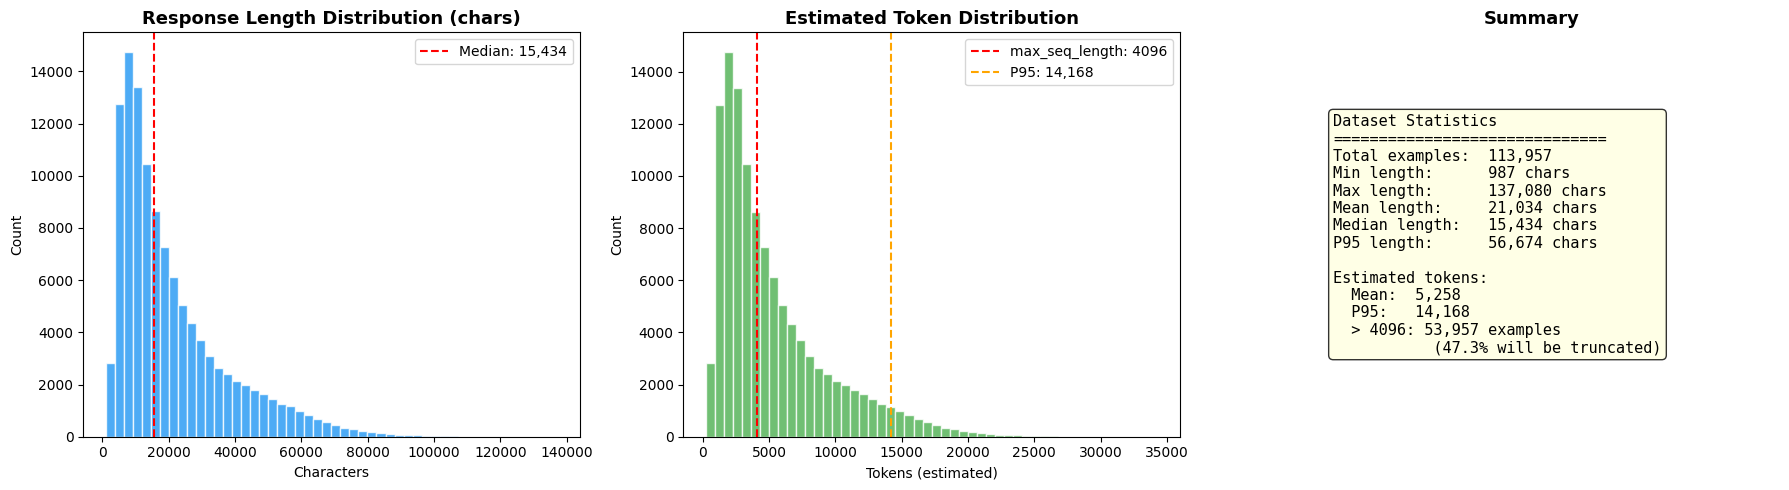

Chart saved to results/dataset_analysis.png


In [7]:
# ============================================================
# STEP 3D: Visualize the dataset
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# Calculate response lengths for all examples in our subset
print("Analyzing dataset statistics...")
response_lengths = [len(ex["conversations"][1]["value"]) for ex in dataset]
token_estimates = [length // 4 for length in response_lengths]  # Rough: 1 token ≈ 4 chars

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Response length distribution (characters)
axes[0].hist(response_lengths, bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].set_title('Response Length Distribution (chars)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Count')
axes[0].axvline(np.median(response_lengths), color='red', linestyle='--', label=f'Median: {np.median(response_lengths):,.0f}')
axes[0].legend()

# Plot 2: Estimated token length distribution
axes[1].hist(token_estimates, bins=50, color='#4CAF50', edgecolor='white', alpha=0.8)
axes[1].set_title('Estimated Token Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tokens (estimated)')
axes[1].set_ylabel('Count')
axes[1].axvline(4096, color='red', linestyle='--', label=f'max_seq_length: 4096')
axes[1].axvline(np.percentile(token_estimates, 95), color='orange', linestyle='--', label=f'P95: {np.percentile(token_estimates, 95):,.0f}')
axes[1].legend()

# Plot 3: Summary statistics
stats_text = f"""Dataset Statistics
{'='*30}
Total examples:  {len(dataset):,}
Min length:      {min(response_lengths):,} chars
Max length:      {max(response_lengths):,} chars
Mean length:     {np.mean(response_lengths):,.0f} chars
Median length:   {np.median(response_lengths):,.0f} chars
P95 length:      {np.percentile(response_lengths, 95):,.0f} chars

Estimated tokens:
  Mean:  {np.mean(token_estimates):,.0f}
  P95:   {np.percentile(token_estimates, 95):,.0f}
  > 4096: {sum(1 for t in token_estimates if t > 4096):,} examples
           ({sum(1 for t in token_estimates if t > 4096)/len(token_estimates)*100:.1f}% will be truncated)"""

axes[2].text(0.1, 0.5, stats_text, transform=axes[2].transAxes,
             fontsize=11, verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[2].axis('off')
axes[2].set_title('Summary', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/dataset_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to results/dataset_analysis.png")

## Step 4: Format the Data for Training

**What's happening here:**

The model doesn't understand raw JSON. We need to convert each conversation into the **chat template** format that Qwen3.5 expects. 

**Qwen3.5's chat template looks like this:**
```
<|im_start|>system
You are a helpful assistant...<|im_end|>
<|im_start|>user
What is 2+2?<|im_end|>
<|im_start|>assistant
<|begin_of_thought|>
Let me think... 2+2 = 4
<|end_of_thought|>

<|begin_of_solution|>
The answer is 4.
<|end_of_solution|><|im_end|>
```

The `tokenizer.apply_chat_template()` function does this conversion automatically — it knows the Qwen format.

**Why `add_generation_prompt=False`?**
During training, we provide the full conversation (including the assistant's answer). We don't want the template to add an empty `<|im_start|>assistant` at the end — the answer is already there.

**The `"text"` column:**
SFTTrainer expects a column named `"text"` containing the fully formatted conversation as a single string. That's what the `formatting_func` produces.

In [10]:
# ============================================================
# STEP 4: Format each example using Qwen's chat template
# ============================================================

def formatting_func(examples):
    """Convert dataset conversations into Qwen3.5 chat template format.
    
    This function:
    1. Takes the system prompt and conversation turns from each example
    2. Builds a list of messages in the standard chat format:
       [{"role": "system", "content": "..."}, {"role": "user", "content": "..."}, {"role": "assistant", "content": "..."}]
    3. Applies Qwen's chat template to produce the final tokenizable string
    """
    texts = []
    for system, convos in zip(examples["system"], examples["conversations"]):
        # Build the message list that the chat template expects
        messages = []
        
        # Add system message (the instruction that tells the model HOW to reason)
        if system:
            messages.append({"role": "system", "content": system})
        
        # Add conversation turns (user question + assistant answer)
        for turn in convos:
            role = "user" if turn["from"] == "user" else "assistant"
            messages.append({"role": role, "content": turn["value"]})
        
        # Apply Qwen's chat template to format everything with special tokens
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,           # Return string, not token IDs (SFTTrainer tokenizes later)
            add_generation_prompt=False  # Don't add empty assistant prompt — answer is already included
        )
        texts.append(text)
    
    return {"text": texts}

# Apply formatting to BOTH training and validation sets
# num_proc=4 means use 4 CPU cores for parallel processing
print("Formatting training set...")
train_dataset = train_dataset.map(formatting_func, batched=True, num_proc=4, remove_columns=train_dataset.column_names)

print("Formatting validation set...")
eval_dataset_split = eval_dataset_split.map(formatting_func, batched=True, num_proc=4, remove_columns=eval_dataset_split.column_names)

print(f"Formatted training set:   {len(train_dataset):,} examples")
print(f"Formatted validation set: {len(eval_dataset_split):,} examples")
print(f"Columns: {train_dataset.column_names}")
print(f"EXAMPLE (first 500 chars)")
print(train_dataset[0]["text"][:500])
print("...")

Formatting training set...


Map (num_proc=4):   0%|          | 0/112817 [00:00<?, ? examples/s]

Formatting validation set...


Map (num_proc=4):   0%|          | 0/1140 [00:00<?, ? examples/s]

Formatted training set:   112,817 examples
Formatted validation set: 1,140 examples
Columns: ['text']
EXAMPLE (first 500 chars)
<|im_start|>system
Your role as an assistant involves thoroughly exploring questions through a systematic long thinking process before providing the final precise and accurate solutions. This requires engaging in a comprehensive cycle of analysis, summarizing, exploration, reassessment, reflection, backtracing, and iteration to develop well-considered thinking process. Please structure your response into two main sections: Thought and Solution. In the Thought section, detail your reasoning proce
...


## Step 5: Configure Training Hyperparameters

**This is the most important step.** These numbers control HOW the model learns.

**Key settings for full 114K dataset training:**

| Parameter | Value | Why |
|-----------|-------|-----|
| Learning rate | 1.5e-4 | Slightly lower than small runs — more data means more total gradient updates |
| Batch size | 4 × 4 = 16 effective | Large enough for stable gradients, fits in VRAM |
| Epochs | 1 | One full pass — more risks overfitting on reasoning data |
| Eval every 500 steps | Monitors validation loss to catch overfitting early |
| Cosine LR schedule | Smooth warmup → peak → decay to ~0 |
| Warmup | 3% of steps | Gradual ramp-up prevents early instability |

**What's different from the 10K run?**
- Lower learning rate (1.5e-4 vs 2e-4) — more data needs gentler updates
- Evaluation enabled — we now have a validation split to track overfitting
- Checkpoints every 1000 steps — best model auto-loaded at the end

In [11]:
# ============================================================
# STEP 5: Configure training arguments
# ============================================================
# Tuned for the FULL 114K dataset with r=32 LoRA.
# Key changes from the 10K run:
#   - Lower learning rate (1.5e-4) to prevent divergence on more data
#   - Higher per-device batch size (4) since we have plenty of VRAM
#   - Eval strategy enabled to monitor overfitting via validation loss
#   - Save checkpoints every 1000 steps (more total steps now)

training_args = TrainingArguments(
    
    # --- OUTPUT ---
    output_dir="../models/qwen35-9b-reasoning-lora",   # Where to save checkpoints
    
    # --- TRAINING DURATION ---
    num_train_epochs=1,              # 1 full pass through 114K examples
                                     # More than 1 epoch risks overfitting on reasoning data
    
    # --- BATCH SIZE ---
    per_device_train_batch_size=4,   # Examples per GPU per step (we have high VRAM)
    gradient_accumulation_steps=4,   # Accumulate before updating. Effective batch = 4 * 4 = 16
    
    # --- LEARNING RATE ---
    learning_rate=1.5e-4,            # Slightly lower than 10K run — more data = more total updates
    lr_scheduler_type="cosine",      # Cosine decay: smooth warmup → peak → decay to ~0
    warmup_ratio=0.03,               # First 3% of steps: ramp up LR from 0 → 1.5e-4
    
    # --- REGULARIZATION ---
    weight_decay=0.01,               # Gentle weight shrinkage to prevent overfitting
    max_grad_norm=1.0,               # Clip gradients if they get too large
    
    # --- PRECISION ---
    bf16=True,                       # bfloat16 — matches model dtype
    fp16=False,
    
    # --- LOGGING ---
    logging_steps=25,                # Print loss every 25 steps (~400 examples)
    logging_first_step=True,         # Print the very first step too
    
    # --- EVALUATION ---
    eval_strategy="steps",           # Run validation during training
    eval_steps=500,                  # Evaluate every 500 steps to track overfitting
    
    # --- CHECKPOINTING ---
    save_steps=1000,                 # Save checkpoint every 1000 steps
    save_total_limit=3,              # Keep only 3 most recent checkpoints
    load_best_model_at_end=True,     # Auto-load the best checkpoint when training ends
    metric_for_best_model="eval_loss",  # "Best" = lowest validation loss
    
    # --- MISC ---
    seed=42,                         # Reproducibility
    report_to="none",                # Set to "wandb" for experiment tracking
    optim="adamw_8bit",              # 8-bit AdamW — saves memory with minimal quality loss
)

# Calculate and display training info
num_examples = len(train_dataset)
effective_batch = training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps
steps_per_epoch = num_examples // effective_batch
total_steps = steps_per_epoch * training_args.num_train_epochs

print(f"Training configuration:")
print(f"  Examples:           {num_examples:,}")
print(f"  Effective batch:    {effective_batch}")
print(f"  Steps per epoch:    {steps_per_epoch:,}")
print(f"  Total steps:        {total_steps:,}")
print(f"  Eval every:         {training_args.eval_steps} steps")
print(f"  Learning rate:      {training_args.learning_rate}")
print(f"  LoRA rank:          32 (alpha=64, scaling=2.0)")
print(f"  Precision:          bf16")
print(f"  Optimizer:          {training_args.optim}")
print(f"  Estimated time:     ~{total_steps * 3 / 3600:.1f}-{total_steps * 5 / 3600:.1f} hours")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training configuration:
  Examples:           112,817
  Effective batch:    16
  Steps per epoch:    7,051
  Total steps:        7,051
  Eval every:         500 steps
  Learning rate:      0.00015
  LoRA rank:          32 (alpha=64, scaling=2.0)
  Precision:          bf16
  Optimizer:          OptimizerNames.ADAMW_8BIT
  Estimated time:     ~5.9-9.8 hours


## Step 6: Create the Trainer and Train!

**What's happening here:**

The SFTTrainer (Supervised Fine-Tuning Trainer) handles the entire training loop:
1. Loads batches of examples
2. Runs them through the model
3. Computes the loss (how wrong the predictions are)
4. Updates the LoRA adapter weights
5. Repeats for all ~113K examples

**Progress tracking:** A custom callback shows you real-time progress:
```
Step 100 | Loss: 0.85 | Examples: 1,600/113,000 (1.4%) | LR: 1.48e-04
```

**Validation:** Every 500 steps, the trainer evaluates on held-out examples. If eval loss starts **rising** while training loss keeps **falling**, that's overfitting — the model is memorizing rather than learning.

**Estimated training time:** ~6-12 hours on your GB10 workstation for the full dataset.

In [13]:
# ============================================================
# STEP 6A: Create the SFT Trainer with Progress Tracking
# ============================================================
from transformers import TrainerCallback

class ProgressCallback(TrainerCallback):
    """Custom callback to show examples processed, not just steps."""
    
    def __init__(self, total_examples):
        self.total_examples = total_examples
    
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            examples_seen = state.global_step * args.per_device_train_batch_size * args.gradient_accumulation_steps
            pct = examples_seen / self.total_examples * 100
            print(
                f"  Step {state.global_step:,} | "
                f"Loss: {logs['loss']:.4f} | "
                f"Examples: {examples_seen:,}/{self.total_examples:,} ({pct:.1f}%) | "
                f"LR: {logs.get('learning_rate', 0):.2e}"
            )
    
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            eval_loss = metrics.get("eval_loss", "N/A")
            print(f"EVAL at step {state.global_step:,} | Eval Loss: {eval_loss:.4f}")

# Unsloth/TRL 0.24+ requires formatting_func instead of dataset_text_field.
# Since our datasets already have a "text" column from Step 4, we just return it.
def sft_formatting_func(examples):
    return examples["text"]

trainer = SFTTrainer(
    model=model,                        # Our Qwen3.5-9B with LoRA r=32 adapters
    args=training_args,                 # All hyperparameters from Step 5
    train_dataset=train_dataset,        # Full ~113K training examples
    eval_dataset=eval_dataset_split,    # ~1.1K validation examples
    processing_class=tokenizer,         # Converts text -> token IDs
    formatting_func=sft_formatting_func,  # Required by Unsloth — returns pre-formatted text
    max_seq_length=max_seq_length,      # Truncate sequences longer than 4096 tokens
    packing=True,                       # Pack multiple short examples into one sequence
    callbacks=[ProgressCallback(len(train_dataset))],  # Custom progress tracking
)

print("Trainer created with progress tracking!")
print(f"  Training examples:   {len(train_dataset):,}")
print(f"  Validation examples: {len(eval_dataset_split):,}")
print(f"  Progress updates every {training_args.logging_steps} steps")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=24):   0%|          | 0/112817 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=24):   0%|          | 0/1140 [00:00<?, ? examples/s]

Trainer created with progress tracking!
  Training examples:   112,817
  Validation examples: 1,140
  Progress updates every 25 steps


In [ ]:
# ============================================================
# STEP 6B: TRAIN! 🚀
# ============================================================
# Full 114K dataset with r=32 LoRA. This will take several hours.
#
# What to watch:
#   - Training loss should decrease from ~1.0 down to ~0.3-0.5
#   - Eval loss should decrease too (if it rises, we're overfitting)
#   - Examples counter shows real progress through the dataset
#
# The progress callback will print:
#   Step 100 | Loss: 0.85 | Examples: 1,600/113,000 (1.4%) | LR: 1.48e-04

print("Starting training on FULL dataset...")
print(f"  Total steps:    ~{total_steps:,}")
print(f"  Eval every:     {training_args.eval_steps} steps")
print(f"  Save every:     {training_args.save_steps} steps")
print(f"  Estimated time: ~{total_steps * 3 / 3600:.1f}-{total_steps * 5 / 3600:.1f} hours")
print("=" * 60)

trainer_stats = trainer.train()

# Print summary
print("\n" + "=" * 60)
print("TRAINING COMPLETE!")
print(f"  Final loss:      {trainer_stats.training_loss:.4f}")
print(f"  Total steps:     {trainer_stats.global_step:,}")
print(f"  Training time:   {trainer_stats.metrics['train_runtime']/60:.1f} minutes")
print(f"  Examples/sec:    {trainer_stats.metrics.get('train_samples_per_second', 0):.2f}")
print(f"  Best checkpoint: {trainer.state.best_model_checkpoint}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.


Starting training on FULL dataset...
  Total steps:    ~7,051
  Eval every:     500 steps
  Save every:     1000 steps
  Estimated time: ~5.9-9.8 hours


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 112,817 | Num Epochs = 1 | Total steps = 7,052
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 58,195,968 of 9,468,009,712 (0.61% trained)


Step,Training Loss,Validation Loss
500,0.369129,0.375930
1000,0.368752,0.372158
1500,0.372125,0.371971
2000,0.360759,0.368769
2500,0.350643,0.366061
3000,0.360936,0.363546
3500,0.354204,0.361420
4000,0.357171,0.358773


  Step 1 | Loss: 0.8863 | Examples: 16/112,817 (0.0%) | LR: 0.00e+00
  Step 25 | Loss: 0.7598 | Examples: 400/112,817 (0.4%) | LR: 1.70e-05
  Step 50 | Loss: 0.4442 | Examples: 800/112,817 (0.7%) | LR: 3.47e-05
  Step 75 | Loss: 0.4104 | Examples: 1,200/112,817 (1.1%) | LR: 5.24e-05
  Step 100 | Loss: 0.3927 | Examples: 1,600/112,817 (1.4%) | LR: 7.00e-05
  Step 125 | Loss: 0.3865 | Examples: 2,000/112,817 (1.8%) | LR: 8.77e-05
  Step 150 | Loss: 0.3783 | Examples: 2,400/112,817 (2.1%) | LR: 1.05e-04
  Step 175 | Loss: 0.3879 | Examples: 2,800/112,817 (2.5%) | LR: 1.23e-04
  Step 200 | Loss: 0.3697 | Examples: 3,200/112,817 (2.8%) | LR: 1.41e-04
  Step 225 | Loss: 0.3762 | Examples: 3,600/112,817 (3.2%) | LR: 1.50e-04
  Step 250 | Loss: 0.3927 | Examples: 4,000/112,817 (3.5%) | LR: 1.50e-04
  Step 275 | Loss: 0.3798 | Examples: 4,400/112,817 (3.9%) | LR: 1.50e-04
  Step 300 | Loss: 0.3706 | Examples: 4,800/112,817 (4.3%) | LR: 1.50e-04
  Step 325 | Loss: 0.3690 | Examples: 5,200/112,81

### Visualize Training Results

Let's plot the training loss curve to see how well the model learned. A good loss curve should:
- Start high (model doesn't know the data yet)
- Decrease smoothly (model is learning)
- Flatten out (model has converged)

We'll also look at learning rate schedule and GPU memory usage.

In [ ]:
# ============================================================
# STEP 6C: Visualize training results
# ============================================================
import matplotlib.pyplot as plt
import json

# Extract training logs
log_history = trainer.state.log_history

# Separate training loss and eval metrics
train_steps = [log["step"] for log in log_history if "loss" in log]
train_losses = [log["loss"] for log in log_history if "loss" in log]
train_lrs = [log.get("learning_rate", 0) for log in log_history if "loss" in log]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Training Loss
axes[0].plot(train_steps, train_losses, color='#E91E63', linewidth=1.5, alpha=0.7)
# Add smoothed line (moving average)
if len(train_losses) > 10:
    window = min(20, len(train_losses) // 5)
    smoothed = np.convolve(train_losses, np.ones(window)/window, mode='valid')
    smoothed_steps = train_steps[window-1:]
    axes[0].plot(smoothed_steps, smoothed, color='#E91E63', linewidth=2.5, label='Smoothed')
axes[0].set_title('Training Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Learning Rate Schedule
axes[1].plot(train_steps, train_lrs, color='#FF9800', linewidth=2)
axes[1].set_title('Learning Rate Schedule (Cosine)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Learning Rate')
axes[1].grid(True, alpha=0.3)

# Plot 3: Training Summary
runtime = trainer_stats.metrics.get('train_runtime', 0)
samples_per_sec = trainer_stats.metrics.get('train_samples_per_second', 0)
steps_per_sec = trainer_stats.metrics.get('train_steps_per_second', 0)

summary = f"""Training Summary
{'='*30}
Final Loss:      {trainer_stats.training_loss:.4f}
Total Steps:     {trainer_stats.global_step}
Training Time:   {runtime/60:.1f} minutes
Samples/sec:     {samples_per_sec:.1f}
Steps/sec:       {steps_per_sec:.3f}

Loss Curve:
  Start:  {train_losses[0]:.4f}
  End:    {train_losses[-1]:.4f}
  Min:    {min(train_losses):.4f}
  Change: {train_losses[0] - train_losses[-1]:.4f}"""

axes[2].text(0.1, 0.5, summary, transform=axes[2].transAxes,
             fontsize=11, verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))
axes[2].axis('off')
axes[2].set_title('Summary', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/training_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to results/training_results.png")

# Also save the log history for later analysis
with open('../results/training_log.json', 'w') as f:
    json.dump(log_history, f, indent=2)
print("Training log saved to results/training_log.json")

## Step 7: Test Your Fine-Tuned Model!

**The moment of truth.** Let's see if the model actually learned to reason better.

We run a few test prompts through the fine-tuned model and inspect the outputs qualitatively. This is a quick sanity check before running the full quantitative evaluation in Step 7C.

**Note:** With the full 114K dataset and r=32 LoRA, you should see noticeably better reasoning chains compared to the 10K run.

In [ ]:
# ============================================================
# STEP 7A: Switch to inference mode
# ============================================================
# Unsloth optimizes the model for 2x faster generation
FastLanguageModel.for_inference(model)

# ============================================================
# STEP 7B: Test with a reasoning problem
# ============================================================

# The tokenizer from Unsloth is a Qwen3VLProcessor (vision-language processor).
# Its apply_chat_template expects multimodal content and breaks on plain strings.
# Use the inner .tokenizer for text-only inference.
text_tokenizer = tokenizer.tokenizer

test_prompts = [
    # Math reasoning
    "A train travels 120 km in 2 hours. Then it travels 180 km in 3 hours. What is the average speed for the entire journey?",
    
    # Logic puzzle
    "If all roses are flowers, and some flowers fade quickly, can we conclude that some roses fade quickly? Explain your reasoning step by step.",
    
    # Coding problem
    "Write a Python function that checks if a number is a palindrome without converting it to a string. Explain your approach.",
]

for i, prompt in enumerate(test_prompts):
    print(f"\n{'='*60}")
    print(f"TEST {i+1}: {prompt[:80]}...")
    print(f"{'='*60}")
    
    # Format the prompt using Qwen's chat template
    messages = [
        {"role": "system", "content": "Your role as an assistant involves thoroughly exploring questions through a systematic long thinking process before providing the final precise and accurate solutions."},
        {"role": "user", "content": prompt},
    ]
    
    # Tokenize and move to GPU
    inputs = text_tokenizer.apply_chat_template(
        messages,
        tokenize=True,               # This time we want token IDs for the model
        add_generation_prompt=True,   # Add "<|im_start|>assistant\n" so the model starts generating
        return_tensors="pt",          # Return PyTorch tensors
    ).to("cuda")
    
    # Generate response
    with torch.no_grad():            # No gradient computation needed for inference
        outputs = model.generate(
            input_ids=inputs,
            max_new_tokens=2048,     # Maximum tokens to generate
            temperature=0.7,         # Controls randomness. 0 = deterministic, 1 = creative
            top_p=0.9,               # Nucleus sampling: only consider top 90% probability tokens
            do_sample=True,          # Enable sampling (vs greedy decoding)
        )
    
    # Decode only the NEW tokens (skip the input prompt)
    response = text_tokenizer.decode(outputs[0][inputs.shape[-1]:], skip_special_tokens=False)
    print(response[:1500])  # Print first 1500 chars
    if len(response) > 1500:
        print(f"\n... [{len(response) - 1500} more characters]")

## Step 7C: Evaluate Your Fine-Tuned Model

**Did fine-tuning actually help?** Qualitative tests (Step 7B) give you a feel, but we need **numbers** to know for sure. We'll compare the **base model** (no fine-tuning) against the **fine-tuned model** (with LoRA adapters) on three benchmarks:

| Benchmark | What it measures | Primary metric |
|-----------|-----------------|----------------|
| **Perplexity** | How confidently the model predicts reasoning text | PPL (lower = better) |
| **Reasoning Accuracy** | Can it solve math/logic problems correctly? | Exact Match % (higher = better) |
| **HumanEval** | Can it write working Python code? | pass@1 % (higher = better) |

### How do we compare without reloading?

Since we used **LoRA** (Low-Rank Adaptation), the original base model weights are untouched — our fine-tuning only added small adapter matrices on top. We can toggle these adapters on/off:

```python
model.disable_adapter_layers()  # → base model behavior
model.enable_adapter_layers()   # → fine-tuned behavior
```

This lets us evaluate both models in seconds without reloading ~18 GB of weights.

In [ ]:
# ============================================================
# STEP 7C: Evaluation Setup
# ============================================================
# Install evalplus for HumanEval code benchmark
# Use sys.executable to ensure we install into the SAME Python as the kernel
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "evalplus", "-q"])

import re
import json
import numpy as np
from pathlib import Path
from datasets import load_dataset
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# We'll use text_tokenizer (defined in Step 7B) for apply_chat_template
# and model is already in inference mode from Step 7A

# Store all results here
eval_results = {}

print("Evaluation setup complete.")

### 7C-i: Perplexity — "How Surprised Is the Model?"

**Perplexity (PPL)** measures how well the model predicts the next token in a sequence.

**The math:** At each token position, the model assigns probabilities to every possible next token. If it gives high probability to the *correct* next token, the loss is low. Perplexity is:

$$PPL = e^{\text{average cross-entropy loss}}$$

**Intuition:**
- **PPL = 1** → the model perfectly predicts every token (impossible in practice)
- **PPL = 10** → on average, the model is as uncertain as choosing between 10 equally likely words
- **Lower PPL = better** — the model is more confident and accurate

**What to expect:**
- Base model on reasoning data: PPL ~8-20 (it can read the text but wasn't trained on this style)
- Fine-tuned model: PPL ~4-10 (it's seen this format before, so it's less surprised)
- A 20-50% reduction in PPL is a strong signal that fine-tuning worked
- PPL below 2 may indicate overfitting — the model memorized rather than learned

**Important:** We compute perplexity using **teacher forcing** — the model always sees the real previous tokens, not its own predictions. This is the standard method.

In [ ]:
# ============================================================
# STEP 7C-i: Perplexity Comparison
# ============================================================
# We load 50 fresh examples from OpenThoughts-114k that were NOT
# in our 10K training subset (we used indices 0-9999 after shuffle
# with seed=42, so we grab from index 10000+).

from torch.nn import CrossEntropyLoss

def compute_perplexity(model, tokenizer, texts, max_length=2048):
    """Compute perplexity over a list of text strings.
    
    How it works:
    1. Tokenize each text
    2. Run through the model to get predicted probabilities for each token
    3. Compute cross-entropy loss (how wrong the predictions are)
    4. Perplexity = e^(average loss)
    
    We use a sliding window for sequences longer than max_length
    to avoid truncating important context.
    """
    model.eval()
    device = next(model.parameters()).device
    loss_fn = CrossEntropyLoss(reduction="none")
    
    total_nll = 0.0  # Total negative log-likelihood
    total_tokens = 0  # Total tokens scored
    
    for text in texts:
        encodings = tokenizer(text, return_tensors="pt", truncation=False)
        seq_len = encodings.input_ids.size(1)
        
        stride = max_length // 4  # Sliding window stride
        
        for begin in range(0, seq_len, stride):
            end = min(begin + max_length, seq_len)
            input_ids = encodings.input_ids[:, begin:end].to(device)
            target_ids = input_ids.clone()
            
            # Mask overlapping tokens (already scored in previous window)
            if begin > 0:
                overlap = max_length - stride
                target_ids[:, :overlap] = -100
            
            with torch.no_grad():
                outputs = model(input_ids)
                # Shift: logits[:-1] predicts labels[1:]
                shift_logits = outputs.logits[:, :-1, :].contiguous()
                shift_labels = target_ids[:, 1:].contiguous()
                
                loss = loss_fn(
                    shift_logits.view(-1, shift_logits.size(-1)),
                    shift_labels.view(-1)
                )
                # Only count non-masked positions
                valid = shift_labels.view(-1) != -100
                total_nll += loss[valid].sum().item()
                total_tokens += valid.sum().item()
            
            if end == seq_len:
                break
    
    return torch.exp(torch.tensor(total_nll / total_tokens)).item()


# --- Load held-out evaluation data ---
print("Loading held-out evaluation examples...")
eval_dataset = load_dataset("open-thoughts/OpenThoughts-114k", split="train")
eval_dataset = eval_dataset.shuffle(seed=42)

# Our training used indices 0-9999, so grab 50 examples from 10000+
eval_examples = eval_dataset.select(range(10000, 10050))

# Format them the same way as training data
eval_texts = []
for ex in eval_examples:
    messages = []
    if ex["system"]:
        messages.append({"role": "system", "content": ex["system"]})
    for turn in ex["conversations"]:
        role = "user" if turn["from"] == "user" else "assistant"
        messages.append({"role": role, "content": turn["value"]})
    text = text_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    eval_texts.append(text)

print(f"Loaded {len(eval_texts)} held-out examples")
print(f"Average length: {np.mean([len(t) for t in eval_texts]):.0f} characters")

# --- Compute perplexity for fine-tuned model ---
print("\nComputing perplexity (fine-tuned model)...")
ppl_finetuned = compute_perplexity(model, text_tokenizer, eval_texts)
print(f"  Fine-tuned PPL: {ppl_finetuned:.2f}")

# --- Compute perplexity for base model ---
print("Computing perplexity (base model — adapters disabled)...")
model.disable_adapter_layers()
ppl_base = compute_perplexity(model, text_tokenizer, eval_texts)
model.enable_adapter_layers()  # Re-enable adapters
print(f"  Base PPL:        {ppl_base:.2f}")

# --- Results ---
ppl_change = ((ppl_finetuned - ppl_base) / ppl_base) * 100
print(f"\n{'='*50}")
print(f"PERPLEXITY COMPARISON")
print(f"{'='*50}")
print(f"  Base model:       {ppl_base:.2f}")
print(f"  Fine-tuned model: {ppl_finetuned:.2f}")
print(f"  Change:           {ppl_change:+.1f}%")
print(f"  {'✓ Fine-tuning reduced perplexity (good!)' if ppl_finetuned < ppl_base else '⚠ Perplexity increased — investigate overfitting'}")

eval_results["perplexity"] = {
    "base": round(ppl_base, 2),
    "finetuned": round(ppl_finetuned, 2),
    "change_pct": round(ppl_change, 1),
}

### 7C-ii: Reasoning Accuracy — "Does It Get the Right Answer?"

We test the model on held-out reasoning problems and check if it produces the **correct final answer**.

**Two metrics, different purposes:**

| Metric | What it measures | Why we use it |
|--------|-----------------|---------------|
| **Final Answer Exact Match** | Did the model get the right answer? | **Primary** — this is what actually matters |
| **ROUGE-L** | Does the reasoning path look similar to the reference? | **Secondary** — checks format and fluency |

#### Final Answer Exact Match
We extract the final answer from both the model's output and the reference using patterns like `\boxed{...}`, "The answer is ...", or the last number/expression. Then we check if they match exactly.

- This is the same approach used by GSM8K, MATH, and other reasoning benchmarks
- A model can have perfect reasoning with zero ROUGE (different wording, same answer)

#### ROUGE-L (Longest Common Subsequence)
ROUGE-L finds the longest sequence of words that appears in both texts (not necessarily contiguous). It captures structural similarity:

```
Reference: "First, we add 120 + 180 = 300. Then divide 300 / 5 = 60 km/h."
Generated: "Adding the distances: 120 + 180 = 300 km. Total time: 5h. Speed = 300/5 = 60 km/h."
ROUGE-L ≈ 0.45 (moderate overlap despite different wording)
```

**Score ranges for reasoning tasks:**
- ROUGE-L 0.2-0.4 is typical (reasoning can be expressed many ways)
- Exact Match > 60% is good for a 9B model on diverse reasoning
- Focus on Exact Match — ROUGE-L is just a sanity check

In [ ]:
# ============================================================
# STEP 7C-ii: Reasoning Accuracy (Exact Match + ROUGE-L)
# ============================================================

def extract_final_answer(text):
    """Extract the final answer from a reasoning response.
    
    Tries multiple patterns in order:
    1. \\boxed{...} — standard math notation
    2. "The answer is ..." / "the final answer is ..."
    3. Last number in the text (fallback)
    """
    # Pattern 1: \boxed{...}
    boxed = re.findall(r'\\boxed\{([^}]+)\}', text)
    if boxed:
        return boxed[-1].strip()
    
    # Pattern 2: "The answer is X" or "the final answer is X"
    answer_match = re.search(
        r'(?:the\s+)?(?:final\s+)?answer\s+is[:\s]+([^\n.]+)',
        text, re.IGNORECASE
    )
    if answer_match:
        return answer_match.group(1).strip()
    
    # Pattern 3: Last number in the text
    numbers = re.findall(r'-?\d+\.?\d*', text)
    if numbers:
        return numbers[-1]
    
    return text.strip()[-100:]  # Last 100 chars as fallback


def normalize_answer(answer):
    """Normalize an answer for comparison."""
    answer = answer.lower().strip()
    answer = re.sub(r'\s+', ' ', answer)          # Collapse whitespace
    answer = re.sub(r'[,$%]', '', answer)          # Remove formatting
    answer = answer.rstrip('.')                     # Remove trailing period
    return answer


# --- Prepare evaluation ---
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

# Use 30 examples that have clear question-answer structure
eval_reasoning = eval_dataset.select(range(10000, 10030))

exact_matches_base = 0
exact_matches_ft = 0
rouge_scores_base = []
rouge_scores_ft = []

print("Evaluating reasoning accuracy (30 examples)...")
print("This generates responses from BOTH models, so it takes a while.\n")

system_prompt = "Your role as an assistant involves thoroughly exploring questions through a systematic long thinking process before providing the final precise and accurate solutions."

for idx, ex in enumerate(eval_reasoning):
    # Get the user question and reference answer
    user_msg = ex["conversations"][0]["value"]
    ref_answer = ex["conversations"][1]["value"]
    ref_final = extract_final_answer(ref_answer)
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_msg},
    ]
    
    inputs = text_tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")
    
    gen_kwargs = dict(
        input_ids=inputs,
        max_new_tokens=1024,
        temperature=0.0,  # Greedy decoding for reproducibility
        do_sample=False,
    )
    
    # --- Fine-tuned model ---
    with torch.no_grad():
        outputs_ft = model.generate(**gen_kwargs)
    response_ft = text_tokenizer.decode(outputs_ft[0][inputs.shape[-1]:], skip_special_tokens=True)
    
    # --- Base model ---
    model.disable_adapter_layers()
    with torch.no_grad():
        outputs_base = model.generate(**gen_kwargs)
    response_base = text_tokenizer.decode(outputs_base[0][inputs.shape[-1]:], skip_special_tokens=True)
    model.enable_adapter_layers()
    
    # --- Score: Exact Match ---
    ft_final = extract_final_answer(response_ft)
    base_final = extract_final_answer(response_base)
    
    if normalize_answer(ft_final) == normalize_answer(ref_final):
        exact_matches_ft += 1
    if normalize_answer(base_final) == normalize_answer(ref_final):
        exact_matches_base += 1
    
    # --- Score: ROUGE-L ---
    rouge_ft = scorer.score(ref_answer, response_ft)['rougeL'].fmeasure
    rouge_base = scorer.score(ref_answer, response_base)['rougeL'].fmeasure
    rouge_scores_ft.append(rouge_ft)
    rouge_scores_base.append(rouge_base)
    
    if (idx + 1) % 5 == 0 or idx == 0:
        em_so_far = (exact_matches_ft / (idx + 1)) * 100
        em_base_so_far = (exact_matches_base / (idx + 1)) * 100
        print(f"  [{idx + 1:2d}/30] Base EM: {em_base_so_far:.0f}% | FT EM: {em_so_far:.0f}% | ROUGE-L base: {np.mean(rouge_scores_base):.3f} ft: {np.mean(rouge_scores_ft):.3f}")

# --- Results ---
n = len(eval_reasoning)
em_base = exact_matches_base / n * 100
em_ft = exact_matches_ft / n * 100
rouge_base_avg = np.mean(rouge_scores_base)
rouge_ft_avg = np.mean(rouge_scores_ft)

print(f"\n{'='*50}")
print(f"REASONING ACCURACY COMPARISON")
print(f"{'='*50}")
print(f"{'Metric':<25} {'Base':>10} {'Fine-tuned':>12} {'Delta':>10}")
print(f"{'-'*57}")
print(f"{'Exact Match %':<25} {em_base:>9.1f}% {em_ft:>11.1f}% {em_ft - em_base:>+9.1f}%")
print(f"{'ROUGE-L (avg)':<25} {rouge_base_avg:>10.3f} {rouge_ft_avg:>12.3f} {rouge_ft_avg - rouge_base_avg:>+10.3f}")

eval_results["reasoning"] = {
    "exact_match_base_pct": round(em_base, 1),
    "exact_match_finetuned_pct": round(em_ft, 1),
    "rouge_l_base": round(rouge_base_avg, 3),
    "rouge_l_finetuned": round(rouge_ft_avg, 3),
    "num_examples": n,
}

### 7C-iii: HumanEval — "Can It Write Working Code?"

**HumanEval** is OpenAI's benchmark of **164 hand-written Python programming problems**. Each problem provides:
- A function signature (e.g., `def has_close_elements(numbers, threshold):`)
- A docstring describing what the function should do
- Hidden test cases that verify correctness

The model must **complete the function body**. We then **actually execute** the generated code against the test cases.

#### What is pass@1?

**pass@1** = the percentage of problems where the model's first attempt passes ALL test cases.

```
Problem: "Write a function that returns the sum of even numbers in a list"
Model generates: return sum(x for x in numbers if x % 2 == 0)
Tests run: ✓ passed 8/8 test cases → counts as a PASS
```

#### Expected scores for 9B-class models:
| Model type | pass@1 |
|---|---|
| Base 9B (not instruction-tuned) | ~55-65% |
| Instruction-tuned 9B | ~75-85% |
| + Reasoning fine-tune (like ours) | Potentially +5-15% |

#### Why execution-based evaluation?
- BLEU/ROUGE can't tell if code actually **works**
- A single wrong character can break a program but barely affect text similarity
- The only honest test of code quality is: **does it run and produce correct output?**

#### Safety note
Generated code is executed in **sandboxed subprocesses** with timeouts. Infinite loops or crashes are caught automatically by evalplus.

#### We use EvalPlus
EvalPlus extends HumanEval with **80x more test cases** per problem, catching edge cases that the original tests miss. This gives a stricter, more realistic score.

In [ ]:
# ============================================================
# STEP 7C-iii: HumanEval Code Benchmark (pass@1)
# ============================================================
# We generate completions for all 164 HumanEval problems,
# then use evalplus to execute them and check correctness.

from evalplus.data import get_human_eval_plus
import tempfile

def generate_humaneval_completions(model, tokenizer, problems, label="model"):
    """Generate code completions for all HumanEval problems.
    
    For each problem, we:
    1. Format the prompt as a chat message asking for ONLY the function body
    2. Generate with temperature=0 (deterministic, for pass@1)
    3. Extract the code from the model's response
    4. Return as a dict mapping task_id → completion string
    """
    completions = {}
    
    for i, (task_id, problem) in enumerate(problems.items()):
        prompt = problem["prompt"]  # Function signature + docstring
        
        messages = [
            {"role": "user", "content": (
                f"Complete the following Python function. "
                f"Return ONLY the function body (the code that goes inside the function). "
                f"Do NOT include the function signature, docstring, or any explanation.\n\n{prompt}"
            )},
        ]
        
        inputs = tokenizer.apply_chat_template(
            messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
        ).to("cuda")
        
        with torch.no_grad():
            outputs = model.generate(
                input_ids=inputs,
                max_new_tokens=512,    # Code solutions are usually short
                temperature=0.0,       # Greedy for pass@1
                do_sample=False,
                eos_token_id=tokenizer.eos_token_id,
            )
        
        response = tokenizer.decode(outputs[0][inputs.shape[-1]:], skip_special_tokens=True)
        
        # Extract code: try markdown block first, then raw text
        code_match = re.search(r"```python\n(.*?)```", response, re.DOTALL)
        if code_match:
            code = code_match.group(1)
        else:
            code_match = re.search(r"```\n(.*?)```", response, re.DOTALL)
            if code_match:
                code = code_match.group(1)
            else:
                code = response
        
        # Clean: remove any re-stated function signature
        lines = code.split("\n")
        clean_lines = []
        for line in lines:
            # Stop at a new top-level function or class definition
            if clean_lines and line.startswith(("def ", "class ", "if __name__")):
                break
            clean_lines.append(line)
        code = "\n".join(clean_lines)
        
        completions[task_id] = code
        
        if (i + 1) % 20 == 0 or (i + 1) == len(problems):
            pct = (i + 1) / len(problems) * 100
            print(f"  [{label}] {i + 1}/{len(problems)} problems ({pct:.0f}%) completed")
    
    return completions


def write_evalplus_jsonl(completions, output_path):
    """Write completions in evalplus JSONL format."""
    with open(output_path, "w") as f:
        for task_id, completion in completions.items():
            f.write(json.dumps({"task_id": task_id, "completion": completion}) + "\n")


def run_evalplus(jsonl_path):
    """Run evalplus evaluation and return pass@1 score."""
    result = subprocess.run(
        ["evalplus.evaluate", "--dataset", "humaneval", "--samples", str(jsonl_path)],
        capture_output=True, text=True, timeout=600,
    )
    # Parse pass@1 from output
    output = result.stdout + result.stderr
    print(output[-500:])  # Show last 500 chars of evalplus output
    
    # evalplus prints: "pass@1: 0.XXX"
    match = re.search(r'pass@1[:\s]+([0-9.]+)', output)
    if match:
        return float(match.group(1))
    return None


# --- Load HumanEval problems ---
print("Loading HumanEval+ problems (164 problems)...")
problems = get_human_eval_plus()
print(f"Loaded {len(problems)} problems\n")

# --- Generate completions: Fine-tuned model ---
print("Generating completions (fine-tuned model)...")
completions_ft = generate_humaneval_completions(model, text_tokenizer, problems, label="fine-tuned")

# --- Generate completions: Base model ---
print("\nGenerating completions (base model — adapters disabled)...")
model.disable_adapter_layers()
completions_base = generate_humaneval_completions(model, text_tokenizer, problems, label="base")
model.enable_adapter_layers()

# --- Write to temp files and evaluate ---
tmp_dir = Path(tempfile.mkdtemp())
ft_path = tmp_dir / "humaneval_finetuned.jsonl"
base_path = tmp_dir / "humaneval_base.jsonl"

write_evalplus_jsonl(completions_ft, ft_path)
write_evalplus_jsonl(completions_base, base_path)

print(f"\n{'='*50}")
print("EVALUATING FINE-TUNED MODEL (executing code)...")
print(f"{'='*50}")
pass1_ft = run_evalplus(ft_path)

print(f"\n{'='*50}")
print("EVALUATING BASE MODEL (executing code)...")
print(f"{'='*50}")
pass1_base = run_evalplus(base_path)

# --- Results ---
print(f"\n{'='*50}")
print(f"HUMANEVAL COMPARISON")
print(f"{'='*50}")
if pass1_ft is not None and pass1_base is not None:
    print(f"  Base model pass@1:       {pass1_base*100:.1f}%")
    print(f"  Fine-tuned model pass@1: {pass1_ft*100:.1f}%")
    print(f"  Delta:                   {(pass1_ft - pass1_base)*100:+.1f}%")
else:
    print("  Could not parse evalplus output. Check logs above.")
    pass1_ft = pass1_ft or 0
    pass1_base = pass1_base or 0

eval_results["humaneval"] = {
    "pass1_base": round((pass1_base or 0) * 100, 1),
    "pass1_finetuned": round((pass1_ft or 0) * 100, 1),
    "num_problems": len(problems),
}

### 7C-iv: GSM8K — "Can It Solve Math Word Problems?"

**GSM8K** (Grade School Math 8K) is a benchmark of **1,319 math word problems** at roughly grade-school to middle-school difficulty. Each problem requires multi-step arithmetic reasoning.

#### Example problem:
> "Janet's ducks lay 16 eggs per day. She eats 3 for breakfast and bakes 4 into muffins. She sells the rest at $2 each. How much does she make per day?"

The model must show its work step-by-step and produce a final numeric answer after `####`.

#### Why GSM8K matters for us:
- **Directly measures math reasoning** — the core skill we fine-tuned for
- OpenThoughts-114k contains many similar math problems, so we expect a big improvement here
- Standard benchmark used by every major LLM evaluation (Open LLM Leaderboard, etc.)

#### Expected scores:
| Model type | GSM8K accuracy |
|---|---|
| Base 9B | ~50-60% |
| Fine-tuned on reasoning (ours) | ~75-85% |

We evaluate on **200 randomly sampled problems** for speed (~15-20 min). The full 1,319 can be run later for final reporting.

In [ ]:
# ============================================================
# STEP 7C-iv: GSM8K Math Reasoning Benchmark
# ============================================================
# 200 problems from GSM8K test set. The model must solve step-by-step
# and produce a final numeric answer.

def extract_gsm8k_answer(text):
    """Extract the final numeric answer from GSM8K format.
    
    Reference answers use '#### <number>' delimiter.
    Model outputs: try #### first, then \boxed{}, then last number.
    """
    # Pattern 1: #### delimiter (standard GSM8K format)
    if "####" in text:
        answer = text.split("####")[-1].strip()
        answer = answer.replace(",", "").replace("$", "").replace("%", "")
        return answer
    
    # Pattern 2: \boxed{...}
    boxed = re.findall(r'\\boxed\{([^}]+)\}', text)
    if boxed:
        return boxed[-1].strip().replace(",", "")
    
    # Pattern 3: "The answer is ..."
    answer_match = re.search(r'(?:the\s+)?(?:final\s+)?answer\s+is[:\s]+([^\n.]+)', text, re.IGNORECASE)
    if answer_match:
        nums = re.findall(r'-?\d+(?:,\d{3})*(?:\.\d+)?', answer_match.group(1))
        if nums:
            return nums[-1].replace(",", "")
    
    # Pattern 4: Last number in text
    numbers = re.findall(r'-?\d+(?:,\d{3})*(?:\.\d+)?', text)
    if numbers:
        return numbers[-1].replace(",", "")
    
    return None


# --- Load GSM8K ---
print("Loading GSM8K test set...")
gsm8k = load_dataset("openai/gsm8k", "main", split="test")
gsm8k_subset = gsm8k.shuffle(seed=42).select(range(200))
print(f"Evaluating {len(gsm8k_subset)} problems (out of {len(gsm8k)} total)\n")

correct_ft = 0
correct_base = 0

system_prompt = "Solve the following math problem step by step. Show your reasoning, then give the final numeric answer after ####."

for idx, ex in enumerate(gsm8k_subset):
    question = ex["question"]
    ref_answer = extract_gsm8k_answer(ex["answer"])
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": question},
    ]
    
    inputs = text_tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")
    
    gen_kwargs = dict(
        input_ids=inputs,
        max_new_tokens=512,
        temperature=0.0,
        do_sample=False,
    )
    
    # Fine-tuned model
    with torch.no_grad():
        out_ft = model.generate(**gen_kwargs)
    resp_ft = text_tokenizer.decode(out_ft[0][inputs.shape[-1]:], skip_special_tokens=True)
    pred_ft = extract_gsm8k_answer(resp_ft)
    
    # Base model
    model.disable_adapter_layers()
    with torch.no_grad():
        out_base = model.generate(**gen_kwargs)
    resp_base = text_tokenizer.decode(out_base[0][inputs.shape[-1]:], skip_special_tokens=True)
    pred_base = extract_gsm8k_answer(resp_base)
    model.enable_adapter_layers()
    
    if pred_ft == ref_answer:
        correct_ft += 1
    if pred_base == ref_answer:
        correct_base += 1
    
    if (idx + 1) % 20 == 0 or idx == 0:
        acc_ft = correct_ft / (idx + 1) * 100
        acc_base = correct_base / (idx + 1) * 100
        print(f"  [{idx + 1:3d}/200] Base: {acc_base:.1f}% | Fine-tuned: {acc_ft:.1f}%")

# --- Results ---
gsm8k_base_acc = correct_base / len(gsm8k_subset) * 100
gsm8k_ft_acc = correct_ft / len(gsm8k_subset) * 100

print(f"\n{'='*50}")
print(f"GSM8K COMPARISON (200 problems)")
print(f"{'='*50}")
print(f"  Base model:       {gsm8k_base_acc:.1f}%")
print(f"  Fine-tuned model: {gsm8k_ft_acc:.1f}%")
print(f"  Delta:            {gsm8k_ft_acc - gsm8k_base_acc:+.1f}%")

eval_results["gsm8k"] = {
    "base_acc": round(gsm8k_base_acc, 1),
    "finetuned_acc": round(gsm8k_ft_acc, 1),
    "num_problems": len(gsm8k_subset),
}

### 7C-v: MMLU — "Did It Forget General Knowledge?"

**MMLU** (Massive Multitask Language Understanding) tests the model across **57 subjects** — from math and science to history and law. It has **14,042 multiple-choice questions** total.

#### Why MMLU matters:
This is our **catastrophic forgetting detector** for general knowledge. Fine-tuning on reasoning data should NOT hurt the model's broad knowledge. If MMLU drops significantly, the model "forgot" things while learning to reason.

#### How it works (log-probability method):
Instead of generating text, we feed the question + all 4 choices and check which answer letter (A/B/C/D) the model assigns the highest probability to. This is:
- **Faster** — single forward pass, no generation
- **More reliable** — no parsing issues, deterministic
- **The standard method** used by Open LLM Leaderboard and lm-evaluation-harness

```
Question: "What is the capital of France?"
A. London  B. Paris  C. Berlin  D. Madrid
→ Model assigns: P(A)=0.02, P(B)=0.91, P(C)=0.04, P(D)=0.03
→ Prediction: B ✓
```

#### Expected scores:
| Model type | MMLU accuracy |
|---|---|
| Base 9B | ~65-72% |
| Fine-tuned on reasoning | ~65-74% (should stay stable or slightly improve) |

We evaluate **200 randomly sampled questions** across all subjects for speed.

In [ ]:
# ============================================================
# STEP 7C-v: MMLU General Knowledge Benchmark
# ============================================================
# 200 questions across 57 subjects. Uses log-probability method
# (single forward pass, no generation needed).

def eval_mmlu_question(model, tokenizer, question, choices):
    """Evaluate a single MMLU question using log-probabilities.
    
    Instead of generating text, we:
    1. Format the question with all 4 choices
    2. Run a single forward pass
    3. Check which answer token (A/B/C/D) has the highest probability
    
    This is deterministic and much faster than generation.
    """
    labels = ["A", "B", "C", "D"]
    prompt = (
        f"{question}\n"
        f"A. {choices[0]}\n"
        f"B. {choices[1]}\n"
        f"C. {choices[2]}\n"
        f"D. {choices[3]}\n"
        f"Answer:"
    )
    
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Get logits for the last token position (where the answer should be)
    logits = outputs.logits[0, -1]
    
    # Get token IDs for A, B, C, D
    token_ids = []
    for label in labels:
        ids = tokenizer.encode(label, add_special_tokens=False)
        token_ids.append(ids[0])
    
    # Compare probabilities
    probs = torch.softmax(logits[token_ids], dim=0)
    prediction = probs.argmax().item()
    
    return prediction


# --- Load MMLU ---
print("Loading MMLU test set...")
mmlu = load_dataset("cais/mmlu", "all", split="test")
mmlu_subset = mmlu.shuffle(seed=42).select(range(200))
print(f"Evaluating {len(mmlu_subset)} questions (out of {len(mmlu)} total)")
print(f"Subjects covered: {len(set(mmlu_subset['subject']))} unique subjects\n")

correct_ft = 0
correct_base = 0

for idx, ex in enumerate(mmlu_subset):
    question = ex["question"]
    choices = ex["choices"]
    answer = ex["answer"]  # Integer 0-3
    
    # Fine-tuned model
    pred_ft = eval_mmlu_question(model, text_tokenizer, question, choices)
    
    # Base model
    model.disable_adapter_layers()
    pred_base = eval_mmlu_question(model, text_tokenizer, question, choices)
    model.enable_adapter_layers()
    
    if pred_ft == answer:
        correct_ft += 1
    if pred_base == answer:
        correct_base += 1
    
    if (idx + 1) % 40 == 0 or idx == 0:
        acc_ft = correct_ft / (idx + 1) * 100
        acc_base = correct_base / (idx + 1) * 100
        print(f"  [{idx + 1:3d}/200] Base: {acc_base:.1f}% | Fine-tuned: {acc_ft:.1f}%")

# --- Results ---
mmlu_base_acc = correct_base / len(mmlu_subset) * 100
mmlu_ft_acc = correct_ft / len(mmlu_subset) * 100

print(f"\n{'='*50}")
print(f"MMLU COMPARISON (200 questions)")
print(f"{'='*50}")
print(f"  Base model:       {mmlu_base_acc:.1f}%")
print(f"  Fine-tuned model: {mmlu_ft_acc:.1f}%")
print(f"  Delta:            {mmlu_ft_acc - mmlu_base_acc:+.1f}%")

if mmlu_base_acc - mmlu_ft_acc > 5:
    print(f"  ⚠ WARNING: MMLU dropped >{mmlu_base_acc - mmlu_ft_acc:.1f}% — possible catastrophic forgetting of general knowledge!")
else:
    print(f"  ✓ General knowledge preserved.")

eval_results["mmlu"] = {
    "base_acc": round(mmlu_base_acc, 1),
    "finetuned_acc": round(mmlu_ft_acc, 1),
    "num_questions": len(mmlu_subset),
}

### 7C-vi: Results Summary

All five benchmarks complete! Here's what to look for:

| Signal | What it means |
|--------|---------------|
| PPL decreased | The model is more confident on reasoning text |
| Exact Match improved | The model gets more correct answers on held-out reasoning |
| GSM8K improved significantly | Math reasoning ability improved — the core goal |
| HumanEval stable or improved | Code ability preserved (no catastrophic forgetting) |
| MMLU stable or improved | General knowledge preserved (no catastrophic forgetting) |

**Red flags:**
- HumanEval drop >10% → lost code ability
- MMLU drop >5% → lost general knowledge
- GSM8K no improvement → fine-tuning didn't help with math reasoning

**Catastrophic forgetting** is when a model loses previously-learned abilities during fine-tuning. We check for it with HumanEval (code) and MMLU (general knowledge).

In [ ]:
# ============================================================
# STEP 7C-vi: Summary Table + Save Results
# ============================================================

print(f"\n{'='*65}")
print(f"  EVALUATION SUMMARY: Base vs Fine-Tuned Qwen3.5-9B")
print(f"  LoRA r=32, alpha=64 | Full 114K dataset | 1 epoch")
print(f"{'='*65}")
print(f"")
print(f"  {'Benchmark':<28} {'Base':>10} {'Fine-tuned':>12} {'Delta':>10}")
print(f"  {'-'*60}")

# Perplexity
ppl = eval_results.get("perplexity", {})
if ppl:
    print(f"  {'Perplexity (↓ better)':<28} {ppl['base']:>10.2f} {ppl['finetuned']:>12.2f} {ppl['change_pct']:>+9.1f}%")

# Reasoning Exact Match
rea = eval_results.get("reasoning", {})
if rea:
    em_delta = rea['exact_match_finetuned_pct'] - rea['exact_match_base_pct']
    rouge_delta = rea['rouge_l_finetuned'] - rea['rouge_l_base']
    print(f"  {'Exact Match % (↑ better)':<28} {rea['exact_match_base_pct']:>9.1f}% {rea['exact_match_finetuned_pct']:>11.1f}% {em_delta:>+9.1f}%")
    print(f"  {'ROUGE-L (↑ better)':<28} {rea['rouge_l_base']:>10.3f} {rea['rouge_l_finetuned']:>12.3f} {rouge_delta:>+10.3f}")

# HumanEval
he = eval_results.get("humaneval", {})
if he:
    he_delta = he['pass1_finetuned'] - he['pass1_base']
    print(f"  {'HumanEval pass@1 (↑)':<28} {he['pass1_base']:>9.1f}% {he['pass1_finetuned']:>11.1f}% {he_delta:>+9.1f}%")

# GSM8K
gs = eval_results.get("gsm8k", {})
if gs:
    gs_delta = gs['finetuned_acc'] - gs['base_acc']
    print(f"  {'GSM8K accuracy (↑)':<28} {gs['base_acc']:>9.1f}% {gs['finetuned_acc']:>11.1f}% {gs_delta:>+9.1f}%")

# MMLU
mm = eval_results.get("mmlu", {})
if mm:
    mm_delta = mm['finetuned_acc'] - mm['base_acc']
    print(f"  {'MMLU accuracy (↑)':<28} {mm['base_acc']:>9.1f}% {mm['finetuned_acc']:>11.1f}% {mm_delta:>+9.1f}%")

print(f"  {'-'*60}")
print()

# Catastrophic forgetting check
warnings = []
if he and (he['pass1_base'] - he['pass1_finetuned']) > 10:
    warnings.append("HumanEval dropped >10% — possible code ability loss!")
if mm and (mm['base_acc'] - mm['finetuned_acc']) > 5:
    warnings.append("MMLU dropped >5% — possible general knowledge loss!")
if gs and (gs['finetuned_acc'] - gs['base_acc']) < 2:
    warnings.append("GSM8K barely improved — fine-tuning may not have helped with math reasoning.")

if warnings:
    for w in warnings:
        print(f"  ⚠ {w}")
else:
    print("  ✓ No catastrophic forgetting detected.")
    if gs and gs['finetuned_acc'] > gs['base_acc'] + 5:
        print("  ✓ Significant math reasoning improvement!")

# Save to JSON
results_path = Path("../results/eval_comparison.json")
results_path.parent.mkdir(parents=True, exist_ok=True)
with open(results_path, "w") as f:
    json.dump(eval_results, f, indent=2)
print(f"\n  Results saved to: {results_path}")

### 7C-vii: Visualize Benchmark Results

Four visualizations to interpret the full evaluation:

1. **Grouped Bar Chart** — Side-by-side comparison across all 5 benchmarks
2. **Radar Chart** — Overall capability profile (larger area = more capable)
3. **ROUGE-L Distribution** — Spread of scores across reasoning examples
4. **Improvement Waterfall** — Shows the delta (improvement or regression) for each benchmark

In [ ]:
# ============================================================
# STEP 7C-vii: Visualize Benchmark Results
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 11})

fig = plt.figure(figsize=(20, 10))

# ── Plot 1: Grouped Bar Chart ──────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)

metrics = []
base_vals = []
ft_vals = []

ppl = eval_results.get("perplexity", {})
if ppl:
    max_ppl = max(ppl["base"], ppl["finetuned"]) * 1.2
    metrics.append("Perplexity\n(inverted)")
    base_vals.append((1 - ppl["base"] / max_ppl) * 100)
    ft_vals.append((1 - ppl["finetuned"] / max_ppl) * 100)

rea = eval_results.get("reasoning", {})
if rea:
    metrics.append("Exact Match\n(%)")
    base_vals.append(rea["exact_match_base_pct"])
    ft_vals.append(rea["exact_match_finetuned_pct"])

he = eval_results.get("humaneval", {})
if he:
    metrics.append("HumanEval\npass@1 (%)")
    base_vals.append(he["pass1_base"])
    ft_vals.append(he["pass1_finetuned"])

gs = eval_results.get("gsm8k", {})
if gs:
    metrics.append("GSM8K\n(%)")
    base_vals.append(gs["base_acc"])
    ft_vals.append(gs["finetuned_acc"])

mm = eval_results.get("mmlu", {})
if mm:
    metrics.append("MMLU\n(%)")
    base_vals.append(mm["base_acc"])
    ft_vals.append(mm["finetuned_acc"])

x = np.arange(len(metrics))
width = 0.35

bars_base = ax1.bar(x - width/2, base_vals, width, label="Base", color="#4A90D9", alpha=0.85)
bars_ft = ax1.bar(x + width/2, ft_vals, width, label="Fine-tuned", color="#E74C3C", alpha=0.85)

ax1.set_ylabel("Score")
ax1.set_title("Base vs Fine-tuned: All Benchmarks")
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=9)
ax1.legend()
ax1.set_ylim(0, 105)

for bar in bars_base:
    h = bar.get_height()
    ax1.annotate(f"{h:.1f}", xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)
for bar in bars_ft:
    h = bar.get_height()
    ax1.annotate(f"{h:.1f}", xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)

# ── Plot 2: Radar Chart ────────────────────────────────────
ax2 = fig.add_subplot(2, 2, 2, polar=True)

if len(metrics) >= 3:
    labels = [m.replace("\n", " ") for m in metrics]
    base_norm = [v / 100 for v in base_vals]
    ft_norm = [v / 100 for v in ft_vals]
    
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    base_norm += base_norm[:1]
    ft_norm += ft_norm[:1]
    angles += angles[:1]
    
    ax2.plot(angles, base_norm, "o-", linewidth=2, label="Base", color="#4A90D9")
    ax2.fill(angles, base_norm, alpha=0.15, color="#4A90D9")
    ax2.plot(angles, ft_norm, "o-", linewidth=2, label="Fine-tuned", color="#E74C3C")
    ax2.fill(angles, ft_norm, alpha=0.15, color="#E74C3C")
    
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(labels, fontsize=8)
    ax2.set_ylim(0, 1)
    ax2.set_title("Model Capability Profile", y=1.08)
    ax2.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)

# ── Plot 3: ROUGE-L Distribution ───────────────────────────
ax3 = fig.add_subplot(2, 2, 3)

if rouge_scores_base and rouge_scores_ft:
    bp = ax3.boxplot(
        [rouge_scores_base, rouge_scores_ft],
        labels=["Base", "Fine-tuned"],
        patch_artist=True, widths=0.5,
    )
    bp["boxes"][0].set_facecolor("#4A90D9")
    bp["boxes"][0].set_alpha(0.6)
    bp["boxes"][1].set_facecolor("#E74C3C")
    bp["boxes"][1].set_alpha(0.6)
    
    ax3.set_ylabel("ROUGE-L F1 Score")
    ax3.set_title("ROUGE-L Distribution (30 examples)")
    
    for i, (scores, color) in enumerate([(rouge_scores_base, "#4A90D9"), (rouge_scores_ft, "#E74C3C")]):
        jitter = np.random.normal(0, 0.04, len(scores))
        ax3.scatter(np.ones(len(scores)) * (i + 1) + jitter, scores,
                    alpha=0.4, s=20, color=color, zorder=3)
    
    for i, scores in enumerate([rouge_scores_base, rouge_scores_ft]):
        median = np.median(scores)
        ax3.annotate(f"med: {median:.3f}", xy=(i + 1, median),
                     xytext=(15, 5), textcoords="offset points", fontsize=9,
                     arrowprops=dict(arrowstyle="->", color="gray"))
else:
    ax3.text(0.5, 0.5, "ROUGE-L scores\nnot available",
             transform=ax3.transAxes, ha="center", va="center")

# ── Plot 4: Improvement Waterfall ──────────────────────────
ax4 = fig.add_subplot(2, 2, 4)

deltas = {}
if rea:
    deltas["Exact\nMatch"] = rea["exact_match_finetuned_pct"] - rea["exact_match_base_pct"]
if gs:
    deltas["GSM8K"] = gs["finetuned_acc"] - gs["base_acc"]
if he:
    deltas["Human\nEval"] = he["pass1_finetuned"] - he["pass1_base"]
if mm:
    deltas["MMLU"] = mm["finetuned_acc"] - mm["base_acc"]

if deltas:
    names = list(deltas.keys())
    vals = list(deltas.values())
    colors = ["#27AE60" if v >= 0 else "#E74C3C" for v in vals]
    
    bars = ax4.bar(names, vals, color=colors, alpha=0.85, edgecolor="white")
    ax4.axhline(y=0, color="black", linewidth=0.5)
    ax4.set_ylabel("Delta (percentage points)")
    ax4.set_title("Improvement from Fine-tuning")
    
    for bar, val in zip(bars, vals):
        h = bar.get_height()
        ax4.annotate(f"{val:+.1f}%",
                     xy=(bar.get_x() + bar.get_width()/2, h),
                     xytext=(0, 5 if h >= 0 else -15),
                     textcoords="offset points", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("../results/eval_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualization saved to: ../results/eval_comparison.png")

## Step 8: Save Your Fine-Tuned Model

**Three saving options:**

1. **LoRA adapter only** (~100 MB) — Saves just the tiny LoRA weights. To use the model, you need the base Qwen3.5-9B + this adapter. Best for sharing and storage.

2. **Merged model (16-bit)** (~18 GB) — Merges LoRA weights back into the base model. Standalone, no dependencies. Best for deployment with vLLM or HuggingFace.

3. **GGUF format** (~5-10 GB depending on quantization) — Converted for use with llama.cpp, Ollama, LM Studio. Best for running on your local machine.

**We'll save all three** so you have maximum flexibility.

In [ ]:
# ============================================================
# STEP 8A: Save LoRA adapter only (~100 MB)
# ============================================================
# This is the lightweight option — just the adapter weights.
# To use later: load base model + load this adapter on top.

lora_save_path = "../models/qwen35-9b-reasoning-lora/final"
model.save_pretrained(lora_save_path)
tokenizer.save_pretrained(lora_save_path)
print(f"LoRA adapter saved to: {lora_save_path}")

In [ ]:
# ============================================================
# STEP 8B: Save merged model in 16-bit (full standalone model)
# ============================================================
# This merges the LoRA weights INTO the base model weights.
# Result: a complete model that doesn't need the adapter anymore.
# Takes more disk (~18 GB) but easier to deploy.

merged_save_path = "../models/qwen35-9b-reasoning-merged"
model.save_pretrained_merged(
    merged_save_path,
    tokenizer,
    save_method="merged_16bit",  # Full 16-bit precision
)
print(f"Merged model saved to: {merged_save_path}")

In [ ]:
# ============================================================
# STEP 8C: Save as GGUF (for Ollama / llama.cpp / LM Studio)
# ============================================================
# GGUF is a quantized format optimized for local inference.
# q8_0 = 8-bit quantization (good quality, ~10 GB)
# q4_k_m = 4-bit quantization (smaller, ~5 GB, slight quality loss)
#
# Uncomment the one you want:

gguf_save_path = "../models/qwen35-9b-reasoning-gguf"

# 8-bit quantization (recommended for quality)
model.save_pretrained_gguf(
    gguf_save_path,
    tokenizer,
    quantization_method="q8_0",
)

# # 4-bit quantization (recommended for size)
# model.save_pretrained_gguf(
#     gguf_save_path,
#     tokenizer,
#     quantization_method="q4_k_m",
# )

print(f"GGUF model saved to: {gguf_save_path}")

## Step 9: Push to HuggingFace Hub (Optional)

If you want to share your model with the world, you can push it directly to HuggingFace.

**Prerequisites:**
1. Create a free account at [huggingface.co](https://huggingface.co)
2. Get your access token from [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens)
3. Run `huggingface-cli login` in your terminal

In [ ]:
# ============================================================
# STEP 9: Push to HuggingFace Hub (OPTIONAL)
# ============================================================
# Uncomment and modify to push your model:

# HF_USERNAME = "yashb98"  # Your HuggingFace username
# MODEL_NAME = "Qwen3.5-9B-Reasoning-LoRA"

# # Push LoRA adapter
# model.push_to_hub(f"{HF_USERNAME}/{MODEL_NAME}", tokenizer=tokenizer)

# # Push merged model
# model.push_to_hub_merged(
#     f"{HF_USERNAME}/{MODEL_NAME}-merged",
#     tokenizer,
#     save_method="merged_16bit",
# )

# # Push GGUF
# model.push_to_hub_gguf(
#     f"{HF_USERNAME}/{MODEL_NAME}-GGUF",
#     tokenizer,
#     quantization_method="q8_0",
# )

print("Uncomment above to push to HuggingFace Hub")

---

## What You Just Learned

| Concept | What it means |
|---------|---------------|
| **SFT** | Teaching a model by showing it input-output examples |
| **LoRA** | Training tiny adapter matrices instead of the full model (0.5% of params) |
| **bf16** | 16-bit precision — half the memory of float32, minimal quality loss |
| **Chat template** | The special token format a model expects (Qwen uses `<\|im_start\|>` / `<\|im_end\|>`) |
| **Gradient accumulation** | Simulating larger batches by accumulating updates over multiple steps |
| **Gradient checkpointing** | Saving memory by recomputing activations instead of storing them |
| **Cosine LR schedule** | Smoothly decaying learning rate — aggressive early, gentle late |
| **Packing** | Fitting multiple short examples into one sequence to reduce padding waste |

## Next Steps

1. **Scale up**: Re-run with full 114K dataset (`dataset.select(range(10000))` → remove that line)
2. **Try 27B**: Change `model_name` to `"Qwen/Qwen3.5-27B"` (needs ~56 GB, you have ~120 GB)
3. **Custom dataset**: Curate your own reasoning data for a specific domain
4. **Evaluation**: Run benchmarks (HumanEval, MMLU, GSM8K) to measure improvement
5. **RL training**: After SFT, use GRPO/DPO to further align the model

## Troubleshooting

| Problem | Solution |
|---------|----------|
| OOM (Out of Memory) | Reduce `per_device_train_batch_size` to 1, reduce `max_seq_length` to 2048 |
| Loss doesn't decrease | Check data formatting, try lower learning rate (1e-4) |
| Loss goes to NaN | Learning rate too high, try 5e-5 |
| Loss goes to 0 | Overfitting — reduce epochs or increase dataset size |
| Slow training | Enable `packing=True`, check GPU utilization with `nvidia-smi` |